# Quadrotor Nonlinear Model

**9-state reduced model** (position removed, keeping velocity/attitude/body-rates):

$$
x = \begin{bmatrix} v_x \\ v_y \\ v_z \\ \phi \\ \theta \\ \psi \\ p \\ q \\ r \end{bmatrix} \in \mathbb{R}^9, \qquad
u = \begin{bmatrix} u_1 \\ u_2 \\ u_3 \\ u_4 \end{bmatrix} \in \mathbb{R}^4
$$

where $u_i$ are individual rotor thrusts, $T = u_1 + u_2 + u_3 + u_4$ is total thrust, and ZYX Euler angles are used.

In [38]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

## Physical Parameters

In [39]:
class QuadrotorParams:
    """Physical parameters for a quadrotor."""
    def __init__(self):
        self.m   = 0.5         # mass [kg]
        self.g   = 9.81        # gravity [m/s^2]
        self.l   = 0.175       # arm length [m]
        self.c_tau = 0.0036    # torque coefficient (yaw)

        # Inertia [kg·m^2]
        self.Jx  = 2.32e-3
        self.Jy  = 2.32e-3
        self.Jz  = 4.00e-3

        # Linear drag coefficients
        self.dx  = 0.01
        self.dy  = 0.01
        self.dz  = 0.01

params = QuadrotorParams()

## Nonlinear Dynamics $\dot{x} = f(x, u)$

State indices: $x_1 = v_x,\ x_2 = v_y,\ x_3 = v_z,\ x_4 = \phi,\ x_5 = \theta,\ x_6 = \psi,\ x_7 = p,\ x_8 = q,\ x_9 = r$

**Translational dynamics** (rotation matrix via ZYX Euler angles, with drag):
$$\dot{v} = \frac{T}{m} R(\phi,\theta,\psi)\,e_3 - g\,e_3 - \frac{1}{m} D_v\, v$$

**Euler-angle kinematics:**
$$\dot{\eta} = W(\phi,\theta)\,\omega, \qquad W = \begin{bmatrix} 1 & \sin\phi\tan\theta & \cos\phi\tan\theta \\ 0 & \cos\phi & -\sin\phi \\ 0 & \frac{\sin\phi}{\cos\theta} & \frac{\cos\phi}{\cos\theta} \end{bmatrix}$$

**Rotational dynamics:**
$$\dot{\omega} = J^{-1}\bigl(\tau(u) - \omega \times (J\omega)\bigr)$$

In [40]:
def quadrotor_dynamics(x, u, p):
    """
    Nonlinear quadrotor dynamics: xdot = f(x, u).

    State  x = [vx, vy, vz, phi, theta, psi, p, q, r]  (9,)
    Input  u = [u1, u2, u3, u4]                          (4,)  per-rotor thrusts
    """
    vx, vy, vz   = x[0], x[1], x[2]
    phi, theta, psi = x[3], x[4], x[5]
    pp, qq, rr    = x[6], x[7], x[8]

    u1, u2, u3, u4 = u[0], u[1], u[2], u[3]
    T = u1 + u2 + u3 + u4

    sphi = np.sin(phi);   cphi = np.cos(phi)
    stheta = np.sin(theta); ctheta = np.cos(theta)
    spsi = np.sin(psi);   cpsi = np.cos(psi)
    ttheta = np.tan(theta)

    # --- Translational dynamics  (R(phi,theta,psi) e3 * T/m  -  g e3  -  Dv/m * v) ---
    f1 = (T / p.m) * (cpsi * stheta * cphi + spsi * sphi) - (p.dx / p.m) * vx
    f2 = (T / p.m) * (spsi * stheta * cphi - cpsi * sphi) - (p.dy / p.m) * vy
    f3 = (T / p.m) * (ctheta * cphi) - p.g - (p.dz / p.m) * vz

    # --- Euler-angle kinematics  (W(phi,theta) * omega) ---
    f4 = pp + qq * sphi * ttheta + rr * cphi * ttheta
    f5 = qq * cphi - rr * sphi
    f6 = qq * (sphi / ctheta) + rr * (cphi / ctheta)

    # --- Rotational dynamics  J^{-1} (tau(u) - omega x (J omega)) ---
    tau_x = p.l * (u2 - u4)
    tau_y = p.l * (u3 - u1)
    tau_z = p.c_tau * (u1 - u2 + u3 - u4)

    f7 = (1.0 / p.Jx) * (tau_x - (p.Jz - p.Jy) * qq * rr)
    f8 = (1.0 / p.Jy) * (tau_y - (p.Jx - p.Jz) * pp * rr)
    f9 = (1.0 / p.Jz) * (tau_z - (p.Jy - p.Jx) * pp * qq)

    return np.array([f1, f2, f3, f4, f5, f6, f7, f8, f9])

## Trim / Equilibrium

At hover the total thrust balances gravity ($T_0 = mg$) and all other states are zero. Each rotor provides $u_i = mg/4$.

In [41]:
def hover_trim(p):
    """Return (x0, u0) at hover equilibrium."""
    x0 = np.zeros(9)
    u_hover = p.m * p.g / 4.0
    u0 = np.array([u_hover, u_hover, u_hover, u_hover])
    return x0, u0

x0, u0 = hover_trim(params)
print(f"Hover thrust per rotor: {u0[0]:.4f} N")
print(f"f(x0, u0) = {quadrotor_dynamics(x0, u0, params)}")  # should be ~0

Hover thrust per rotor: 1.2263 N
f(x0, u0) = [0. 0. 0. 0. 0. 0. 0. 0. 0.]


## Linearization $A = \frac{\partial f}{\partial x}\bigg|_{x_0,u_0}, \quad B = \frac{\partial f}{\partial u}\bigg|_{x_0,u_0}$

Compute Jacobians via finite differences so the linearization works at *any* operating point.

In [42]:
def linearize(f, x0, u0, p, eps=1e-6):
    """
    Numerically linearize xdot = f(x, u, p) about (x0, u0).
    Returns A (n x n), B (n x m).
    """
    n = x0.shape[0]
    m = u0.shape[0]
    f0 = f(x0, u0, p)

    A = np.zeros((n, n))
    for j in range(n):
        xp = x0.copy(); xp[j] += eps
        xm = x0.copy(); xm[j] -= eps
        A[:, j] = (f(xp, u0, p) - f(xm, u0, p)) / (2.0 * eps)

    B = np.zeros((n, m))
    for j in range(m):
        up = u0.copy(); up[j] += eps
        um = u0.copy(); um[j] -= eps
        B[:, j] = (f(x0, up, p) - f(x0, um, p)) / (2.0 * eps)

    return A, B

### Linearization at hover

In [43]:
A_hover, B_hover = linearize(quadrotor_dynamics, x0, u0, params)

np.set_printoptions(precision=4, suppress=True, linewidth=120)
print("A =")
print(A_hover)
print("\nB =")
print(B_hover)

A =
[[-0.02  0.    0.    0.    9.81  0.    0.    0.    0.  ]
 [ 0.   -0.02  0.   -9.81  0.    0.    0.    0.    0.  ]
 [ 0.    0.   -0.02  0.    0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.    1.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.    0.    1.    0.  ]
 [ 0.    0.    0.    0.    0.    0.    0.    0.    1.  ]
 [ 0.    0.    0.    0.    0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.    0.    0.    0.  ]]

B =
[[  0.      0.      0.      0.   ]
 [  0.      0.      0.      0.   ]
 [  2.      2.      2.      2.   ]
 [  0.      0.      0.      0.   ]
 [  0.      0.      0.      0.   ]
 [  0.      0.      0.      0.   ]
 [  0.     75.431   0.    -75.431]
 [-75.431   0.     75.431   0.   ]
 [  0.9    -0.9     0.9    -0.9  ]]


### Linearization at multiple operating points

Useful for gain-scheduled control. Define a set of trim conditions, linearize around each.

In [44]:
trim_points = {
    "hover":      (np.zeros(9), u0.copy()),
    "roll_15":    (np.array([0, 0, 0, np.radians(15), 0, 0, 0, 0, 0]), u0.copy()),
    "pitch_15":   (np.array([0, 0, 0, 0, np.radians(15), 0, 0, 0, 0]), u0.copy()),
    "yaw_30":     (np.array([0, 0, 0, 0, 0, np.radians(30), 0, 0, 0]), u0.copy()),
    "fwd_flight": (np.array([2.0, 0, 0, 0, np.radians(10), 0, 0, 0, 0]), u0.copy()),
}

linearized_models = {}
for name, (x_trim, u_trim) in trim_points.items():
    A, B = linearize(quadrotor_dynamics, x_trim, u_trim, params)
    linearized_models[name] = (A, B)
    eigs = np.linalg.eigvals(A)
    print(f"{name:12s}  |  open-loop eigenvalues (real parts): {np.sort(eigs.real)}")

hover         |  open-loop eigenvalues (real parts): [-0.02 -0.02 -0.02  0.    0.    0.    0.    0.    0.  ]
roll_15       |  open-loop eigenvalues (real parts): [-0.02 -0.02 -0.02  0.    0.    0.    0.    0.    0.  ]
pitch_15      |  open-loop eigenvalues (real parts): [-0.02 -0.02 -0.02  0.    0.    0.    0.    0.    0.  ]
yaw_30        |  open-loop eigenvalues (real parts): [-0.02 -0.02 -0.02  0.    0.    0.    0.    0.    0.  ]
fwd_flight    |  open-loop eigenvalues (real parts): [-0.02 -0.02 -0.02  0.    0.    0.    0.    0.    0.  ]


## Nonlinear Simulation

Integrate the full nonlinear dynamics using `solve_ivp`. Test with a small perturbation from hover to verify the open-loop response.

In [45]:
def simulate(f, x_init, u_func, p, t_span, dt=0.005):
    """
    Simulate xdot = f(x, u, p) with a callable u_func(t, x) -> u.
    Returns t_eval, x_hist (N x n), u_hist (N x m).
    """
    t_eval = np.arange(t_span[0], t_span[1], dt)

    def rhs(t, x):
        u = u_func(t, x)
        return f(x, u, p)

    sol = solve_ivp(rhs, t_span, x_init, t_eval=t_eval, max_step=dt)

    u_hist = np.array([u_func(t, x) for t, x in zip(sol.t, sol.y.T)])
    return sol.t, sol.y.T, u_hist

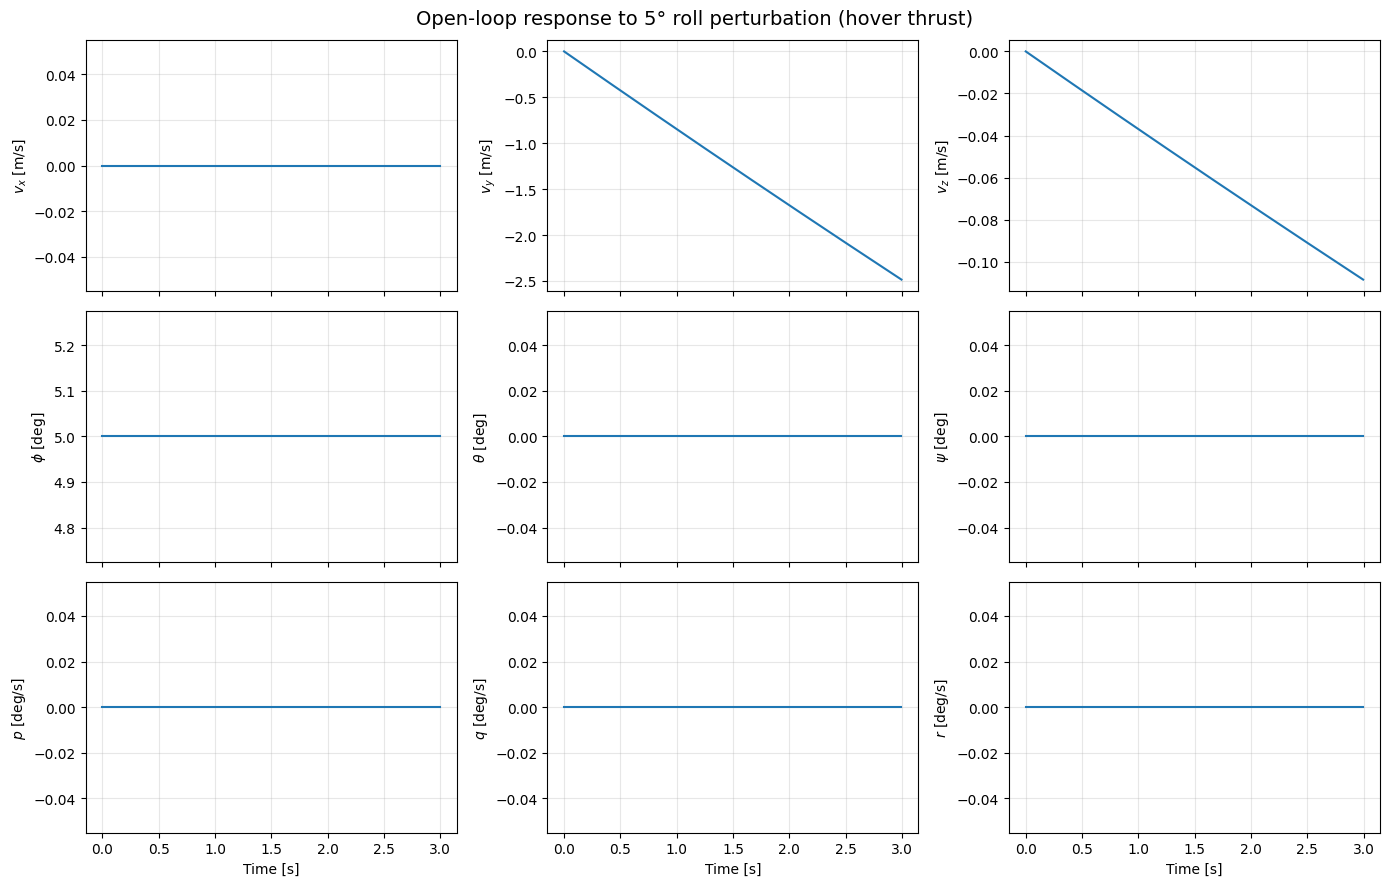

In [46]:
x_perturbed = x0.copy()
x_perturbed[3] = np.radians(5)   # 5° roll perturbation

def hover_input(t, x):
    return u0.copy()

t, x_hist, u_hist = simulate(quadrotor_dynamics, x_perturbed, hover_input, params, (0, 3.0))

state_labels = [r"$v_x$", r"$v_y$", r"$v_z$",
                r"$\phi$", r"$\theta$", r"$\psi$",
                r"$p$", r"$q$", r"$r$"]

fig, axes = plt.subplots(3, 3, figsize=(14, 9), sharex=True)
for i, ax in enumerate(axes.flat):
    vals = np.degrees(x_hist[:, i]) if i in (3, 4, 5) else x_hist[:, i]
    unit = " [deg]" if i in (3, 4, 5) else (" [deg/s]" if i in (6, 7, 8) else " [m/s]")
    ax.plot(t, vals)
    ax.set_ylabel(state_labels[i] + unit)
    ax.grid(True, alpha=0.3)

for ax in axes[-1]:
    ax.set_xlabel("Time [s]")

fig.suptitle("Open-loop response to 5° roll perturbation (hover thrust)", fontsize=14)
fig.tight_layout()
plt.show()

## Controllability Check

Verify that the linearized system at hover is controllable.

In [47]:
def controllability_matrix(A, B):
    n = A.shape[0]
    C = B.copy()
    Ak = np.eye(n)
    for _ in range(n - 1):
        Ak = Ak @ A
        C = np.hstack([C, Ak @ B])
    return C

for name, (A, B) in linearized_models.items():
    C = controllability_matrix(A, B)
    rank = np.linalg.matrix_rank(C)
    print(f"{name:12s}  |  controllability rank = {rank} / {A.shape[0]}  {'✓ controllable' if rank == A.shape[0] else '✗ NOT controllable'}")

hover         |  controllability rank = 9 / 9  ✓ controllable
roll_15       |  controllability rank = 9 / 9  ✓ controllable
pitch_15      |  controllability rank = 9 / 9  ✓ controllable
yaw_30        |  controllability rank = 9 / 9  ✓ controllable
fwd_flight    |  controllability rank = 9 / 9  ✓ controllable


---

# Step 3: LQG Controller

The architecture from the whiteboard:

$$u = u_0 + \delta u, \qquad \delta u = -K\bigl(\hat{x} - x_{\text{target}}\bigr)$$

1. **LQR** — design gain $K$ from the linearized $(A, B)$ by minimizing $\int (x^T Q x + u^T R u)\, dt$
2. **Kalman Filter (KF)** — estimate $\hat{x}$ from noisy measurements $y = Cx + n$
3. **LQG** — combine LQR + KF in a closed loop around the **nonlinear** plant

In [48]:
from scipy.linalg import solve_continuous_are

## LQR Design

Solve the continuous-time algebraic Riccati equation (CARE):
$$A^T P + P A - P B R^{-1} B^T P + Q = 0, \qquad K = R^{-1} B^T P$$

In [49]:
def design_lqr(A, B, Q, R):
    """Solve CARE and return (K, P) for the LQR gain."""
    P = solve_continuous_are(A, B, Q, R)
    K = np.linalg.solve(R, B.T @ P)
    return K, P

# Tuning weights
#   Q penalises state deviations:  [vx, vy, vz, phi, theta, psi, p, q, r]
#   R penalises control effort:    [u1, u2, u3, u4]
Q_lqr = np.diag([10.0, 10.0, 10.0,   # velocity tracking
                  50.0, 50.0, 20.0,   # attitude tracking
                   1.0,  1.0,  1.0])  # body-rate damping

R_lqr = np.diag([1.0, 1.0, 1.0, 1.0])

K_hover, P_hover = design_lqr(A_hover, B_hover, Q_lqr, R_lqr)

print("LQR gain K (9×4 → 4×9):")
print(K_hover)

eigs_cl = np.linalg.eigvals(A_hover - B_hover @ K_hover)
print(f"\nClosed-loop eigenvalues (real parts): {np.sort(eigs_cl.real)}")

LQR gain K (9×4 → 4×9):
[[-2.2205 -0.      1.5786  0.     -7.668   2.2361  0.     -0.7757  1.2216]
 [-0.     -2.2205  1.5786  7.668  -0.     -2.2361  0.7757 -0.     -1.2216]
 [ 2.2205 -0.      1.5786  0.      7.668   2.2361  0.      0.7757  1.2216]
 [-0.      2.2205  1.5786 -7.668  -0.     -2.2361 -0.7757 -0.     -1.2216]]

Closed-loop eigenvalues (real parts): [-106.4403 -106.4403  -12.6491   -5.299    -5.299    -5.299    -5.299    -2.1988   -2.1988]


## Kalman Filter Design

The measurement model (from the whiteboard): $y = Cx + n$, where $n$ is sensor noise.

We assume all 9 states are measured (full-state output, $C = I$) with additive noise. The KF uses:
- **Process noise** covariance $Q_{\text{kf}}$ (disturbances on the state)
- **Measurement noise** covariance $R_{\text{kf}}$ (sensor noise)

The steady-state Kalman gain $L$ is found by solving the dual CARE:
$$A P_f + P_f A^T - P_f C^T R_{\text{kf}}^{-1} C P_f + Q_{\text{kf}} = 0, \qquad L = P_f C^T R_{\text{kf}}^{-1}$$

In [50]:
def design_kalman(A, C, Qkf, Rkf):
    """Steady-state Kalman gain via the dual CARE."""
    Pf = solve_continuous_are(A.T, C.T, Qkf, Rkf)
    L = Pf @ C.T @ np.linalg.inv(Rkf)
    return L, Pf

n_states = 9
C_meas = np.eye(n_states)

# Process noise: moderate disturbance on velocities and body rates
Q_kf = np.diag([0.1, 0.1, 0.1,     # velocity process noise
                0.01, 0.01, 0.01,   # attitude process noise
                0.1, 0.1, 0.1])     # body-rate process noise

# Measurement noise: sensor accuracy
R_kf = np.diag([0.05, 0.05, 0.05,   # velocity measurement noise
                0.01, 0.01, 0.01,    # attitude measurement noise (IMU is good)
                0.02, 0.02, 0.02])   # gyro measurement noise

L_hover, Pf_hover = design_kalman(A_hover, C_meas, Q_kf, R_kf)

print("Kalman gain L (9×9):")
print(L_hover)

eigs_kf = np.linalg.eigvals(A_hover - L_hover @ C_meas @ A_hover)
print(f"\nKF observer eigenvalues: see estimator poles below")
eigs_obs = np.linalg.eigvals(A_hover - L_hover @ C_meas)
print(f"Observer eigenvalues (real parts): {np.sort(eigs_obs.real)}")

Kalman gain L (9×9):
[[ 3.2487  0.      0.      0.      2.6143  0.      0.      0.7204  0.    ]
 [ 0.      3.2487  0.     -2.6143  0.      0.     -0.7204  0.      0.    ]
 [ 0.      0.      1.3944  0.      0.      0.      0.      0.      0.    ]
 [ 0.     -0.5229  0.      1.094   0.      0.      0.533   0.      0.    ]
 [ 0.5229  0.      0.      0.      1.094   0.      0.      0.533   0.    ]
 [ 0.      0.      0.      0.      0.      1.6183  0.      0.      0.5635]
 [ 0.     -0.2882  0.      1.066   0.      0.      2.0553  0.      0.    ]
 [ 0.2882  0.      0.      0.      1.066   0.      0.      2.0553  0.    ]
 [ 0.      0.      0.      0.      0.      1.127   0.      0.      2.0892]]

KF observer eigenvalues: see estimator poles below
Observer eigenvalues (real parts): [-2.7386 -2.7386 -1.8538 -1.8538 -1.8397 -1.8397 -1.8397 -1.8397 -1.4144]


## Full LQG Closed-Loop Simulation

Run the **nonlinear** plant with:
- Kalman Filter producing $\hat{x}$ from noisy measurements
- LQR producing $\delta u = -K(\hat{x} - x_{\text{target}})$
- Total input $u = u_0 + \delta u$
- Process noise $w$ and measurement noise $n$ injected

This matches the whiteboard block diagram.

In [51]:
def simulate_lqg(f, x_init, x_target, u0, K, L, C, A_lin, B_lin,
                  p, Q_kf_chol, R_kf_chol, t_span, dt=0.005, seed=42):
    """
    Closed-loop LQG simulation around the nonlinear plant.

    KF prediction uses the linearized model; the plant is nonlinear.
    δu = -K (x̂ - x_target),  u = u0 + δu
    """
    rng = np.random.default_rng(seed)
    n = x_init.shape[0]
    m = u0.shape[0]

    t_eval = np.arange(t_span[0], t_span[1], dt)
    N = len(t_eval)

    x_hist  = np.zeros((N, n))
    xhat_hist = np.zeros((N, n))
    u_hist  = np.zeros((N, m))
    y_hist  = np.zeros((N, n))

    x = x_init.copy()
    xhat = np.zeros(n)  # KF starts at zero (unknown initial state)

    for k in range(N):
        # --- Measurement: y = C x + noise ---
        meas_noise = R_kf_chol @ rng.standard_normal(n)
        y = C @ x + meas_noise

        # --- KF innovation update ---
        y_pred = C @ xhat
        innovation = y - y_pred
        xhat = xhat + L @ innovation

        # --- LQR control law: δu = -K (x̂ - x_target) ---
        delta_u = -K @ (xhat - x_target)
        u = u0 + delta_u
        u = np.clip(u, 0.0, None)  # rotor thrusts can't be negative

        # --- Store ---
        x_hist[k] = x
        xhat_hist[k] = xhat
        u_hist[k] = u
        y_hist[k] = y

        # --- Propagate true state (nonlinear plant + process noise) ---
        proc_noise = Q_kf_chol @ rng.standard_normal(n)
        xdot = f(x, u, p) + proc_noise
        x = x + xdot * dt

        # --- Propagate KF prediction (linearized model) ---
        xhat_dot = A_lin @ (xhat - x_target) + B_lin @ delta_u
        xhat = xhat + xhat_dot * dt  # note: this overwrites with prediction step

    return t_eval, x_hist, xhat_hist, u_hist, y_hist

### Test: Stabilize from a perturbed initial condition with noise

In [52]:
# Noise Cholesky factors (square root of covariance, scaled for discrete step)
Q_kf_chol = np.linalg.cholesky(Q_kf) * np.sqrt(0.005)
R_kf_chol = np.linalg.cholesky(R_kf)

# Initial condition: perturbed from hover
x_ic = np.array([0.5, -0.3, 0.2,               # some velocity
                 np.radians(10), np.radians(-5), np.radians(8),  # tilted
                 0.1, -0.1, 0.05])               # spinning slightly

x_target = np.zeros(9)  # goal: hover at origin

t_lqg, x_lqg, xhat_lqg, u_lqg, y_lqg = simulate_lqg(
    quadrotor_dynamics, x_ic, x_target, u0,
    K_hover, L_hover, C_meas, A_hover, B_hover,
    params, Q_kf_chol, R_kf_chol,
    t_span=(0, 5.0), dt=0.005
)

/var/folders/cr/2v0p62js4yg161nws06lqptw0000gn/T/ipykernel_1210/496710065.py:35: RuntimeWarning: overflow encountered in scalar multiply
  f7 = (1.0 / p.Jx) * (tau_x - (p.Jz - p.Jy) * qq * rr)
/var/folders/cr/2v0p62js4yg161nws06lqptw0000gn/T/ipykernel_1210/496710065.py:36: RuntimeWarning: overflow encountered in scalar multiply
  f8 = (1.0 / p.Jy) * (tau_y - (p.Jx - p.Jz) * pp * rr)
/var/folders/cr/2v0p62js4yg161nws06lqptw0000gn/T/ipykernel_1210/2982846537.py:27: RuntimeWarning: invalid value encountered in matmul
  y = C @ x + meas_noise
/var/folders/cr/2v0p62js4yg161nws06lqptw0000gn/T/ipykernel_1210/496710065.py:26: RuntimeWarning: invalid value encountered in scalar add
  f4 = pp + qq * sphi * ttheta + rr * cphi * ttheta
/var/folders/cr/2v0p62js4yg161nws06lqptw0000gn/T/ipykernel_1210/496710065.py:37: RuntimeWarning: invalid value encountered in scalar multiply
  f9 = (1.0 / p.Jz) * (tau_z - (p.Jy - p.Jx) * pp * qq)
/var/folders/cr/2v0p62js4yg161nws06lqptw0000gn/T/ipykernel_1210/4967

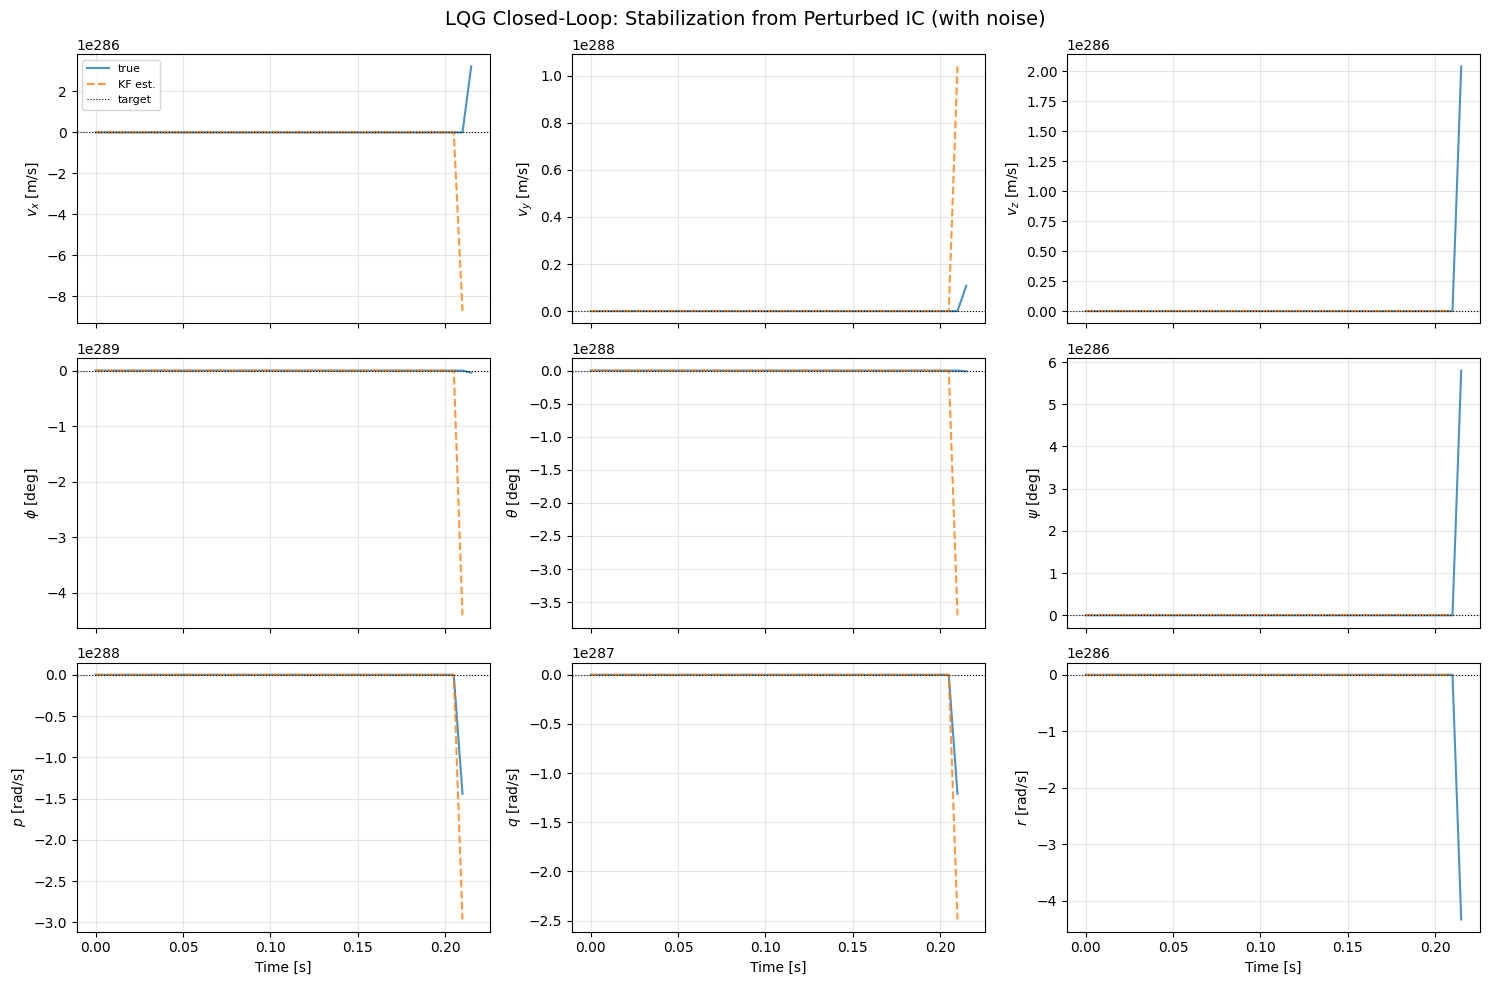

In [53]:
state_labels = [r"$v_x$", r"$v_y$", r"$v_z$",
                r"$\phi$", r"$\theta$", r"$\psi$",
                r"$p$", r"$q$", r"$r$"]

fig, axes = plt.subplots(3, 3, figsize=(15, 10), sharex=True)
for i, ax in enumerate(axes.flat):
    is_angle = i in (3, 4, 5)
    scale = np.degrees(1) if is_angle else 1.0
    unit = " [deg]" if is_angle else (" [rad/s]" if i in (6, 7, 8) else " [m/s]")

    ax.plot(t_lqg, x_lqg[:, i] * scale, label="true", alpha=0.8)
    ax.plot(t_lqg, xhat_lqg[:, i] * scale, '--', label="KF est.", alpha=0.8)
    ax.axhline(x_target[i] * scale, color='k', ls=':', lw=0.8, label="target")
    ax.set_ylabel(state_labels[i] + unit)
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(fontsize=8)

for ax in axes[-1]:
    ax.set_xlabel("Time [s]")

fig.suptitle("LQG Closed-Loop: Stabilization from Perturbed IC (with noise)", fontsize=14)
fig.tight_layout()
plt.show()

### Control inputs

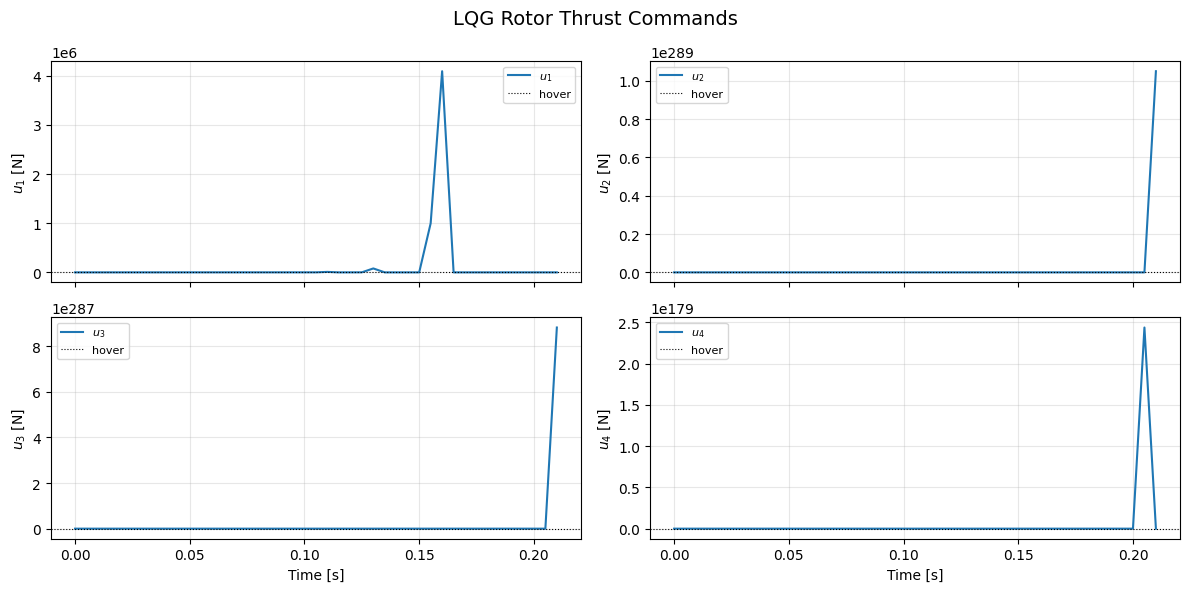

In [54]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True)
for i, ax in enumerate(axes.flat):
    ax.plot(t_lqg, u_lqg[:, i], label=f"$u_{i+1}$")
    ax.axhline(u0[i], color='k', ls=':', lw=0.8, label="hover")
    ax.set_ylabel(f"$u_{i+1}$ [N]")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

for ax in axes[-1]:
    ax.set_xlabel("Time [s]")

fig.suptitle("LQG Rotor Thrust Commands", fontsize=14)
fig.tight_layout()
plt.show()

### Estimation error

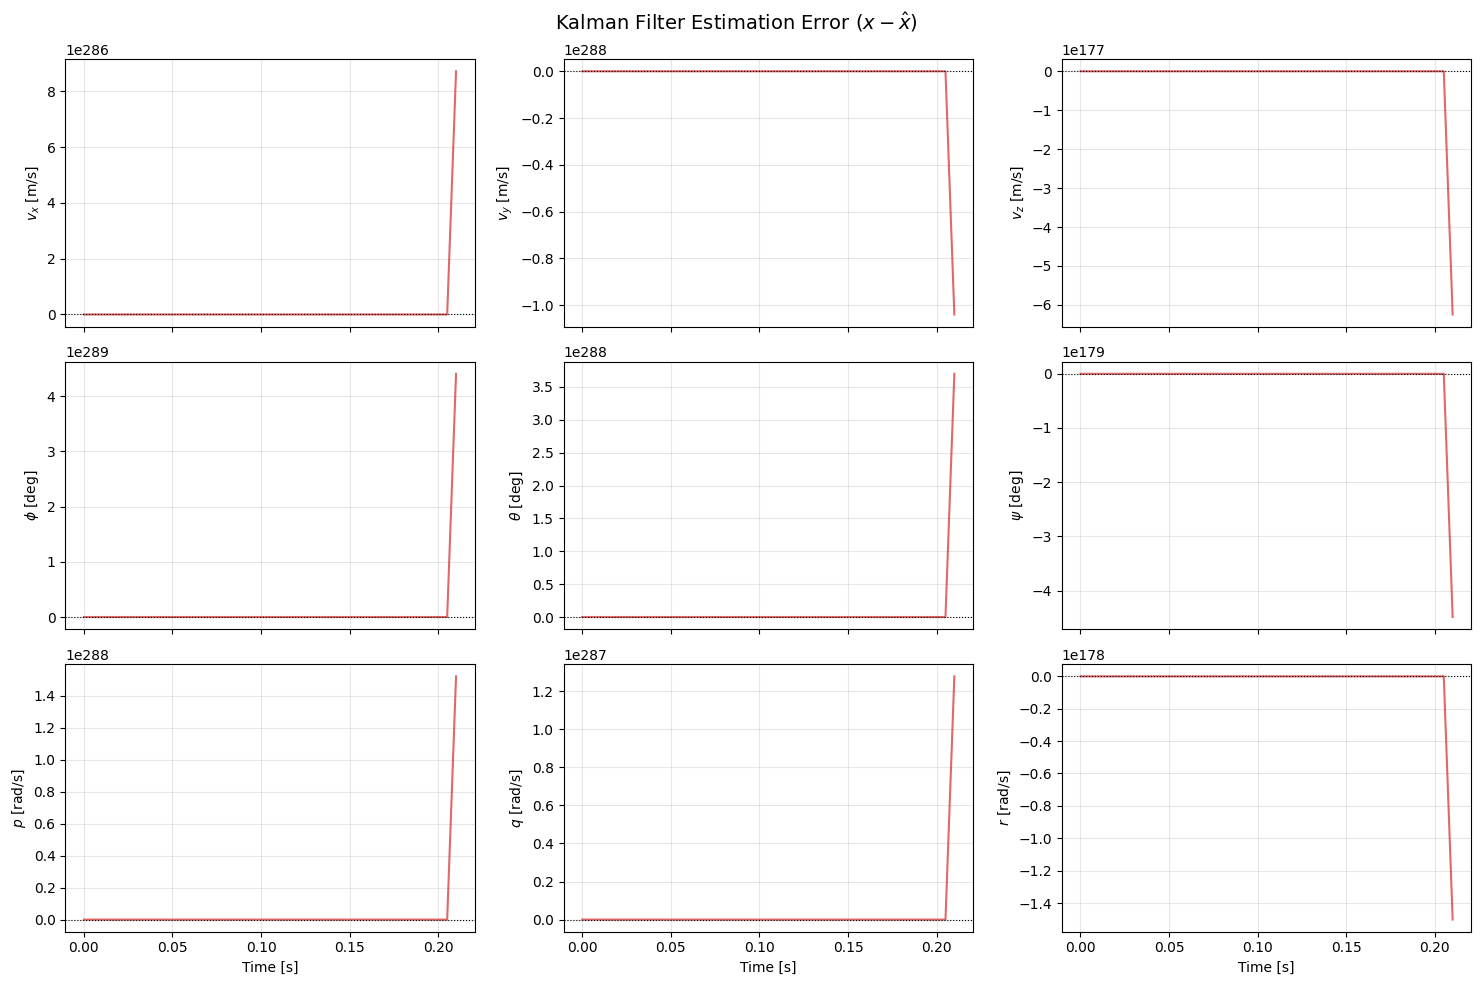

In [55]:
est_error = x_lqg - xhat_lqg

fig, axes = plt.subplots(3, 3, figsize=(15, 10), sharex=True)
for i, ax in enumerate(axes.flat):
    is_angle = i in (3, 4, 5)
    scale = np.degrees(1) if is_angle else 1.0
    unit = " [deg]" if is_angle else (" [rad/s]" if i in (6, 7, 8) else " [m/s]")

    ax.plot(t_lqg, est_error[:, i] * scale, color='tab:red', alpha=0.7)
    ax.axhline(0, color='k', ls=':', lw=0.8)
    ax.set_ylabel(state_labels[i] + unit)
    ax.grid(True, alpha=0.3)

for ax in axes[-1]:
    ax.set_xlabel("Time [s]")

fig.suptitle("Kalman Filter Estimation Error ($x - \\hat{x}$)", fontsize=14)
fig.tight_layout()
plt.show()

## LQG at All 5 Trim Points

Design an LQR + KF at each of the 5 linearization points and verify closed-loop stability.

In [56]:
lqg_designs = {}

for name, (A, B) in linearized_models.items():
    K, P = design_lqr(A, B, Q_lqr, R_lqr)
    L, Pf = design_kalman(A, C_meas, Q_kf, R_kf)
    lqg_designs[name] = {"K": K, "L": L, "A": A, "B": B}

    cl_eigs = np.linalg.eigvals(A - B @ K)
    obs_eigs = np.linalg.eigvals(A - L @ C_meas)
    max_cl = np.max(cl_eigs.real)
    max_obs = np.max(obs_eigs.real)
    stable_cl = "✓" if max_cl < 0 else "✗"
    stable_obs = "✓" if max_obs < 0 else "✗"
    print(f"{name:12s}  |  CL max Re(λ)={max_cl:+.4f} {stable_cl}  |  KF max Re(λ)={max_obs:+.4f} {stable_obs}")

hover         |  CL max Re(λ)=-2.1988 ✓  |  KF max Re(λ)=-1.4144 ✓
roll_15       |  CL max Re(λ)=-2.2274 ✓  |  KF max Re(λ)=-1.4144 ✓
pitch_15      |  CL max Re(λ)=-2.2559 ✓  |  KF max Re(λ)=-1.4144 ✓
yaw_30        |  CL max Re(λ)=-2.1988 ✓  |  KF max Re(λ)=-1.4144 ✓
fwd_flight    |  CL max Re(λ)=-2.2249 ✓  |  KF max Re(λ)=-1.4144 ✓
